In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
df = pd.read_csv('final_data_fixed.csv')

#Оценка важности признаков

Смотрим количество признаков в пропусках

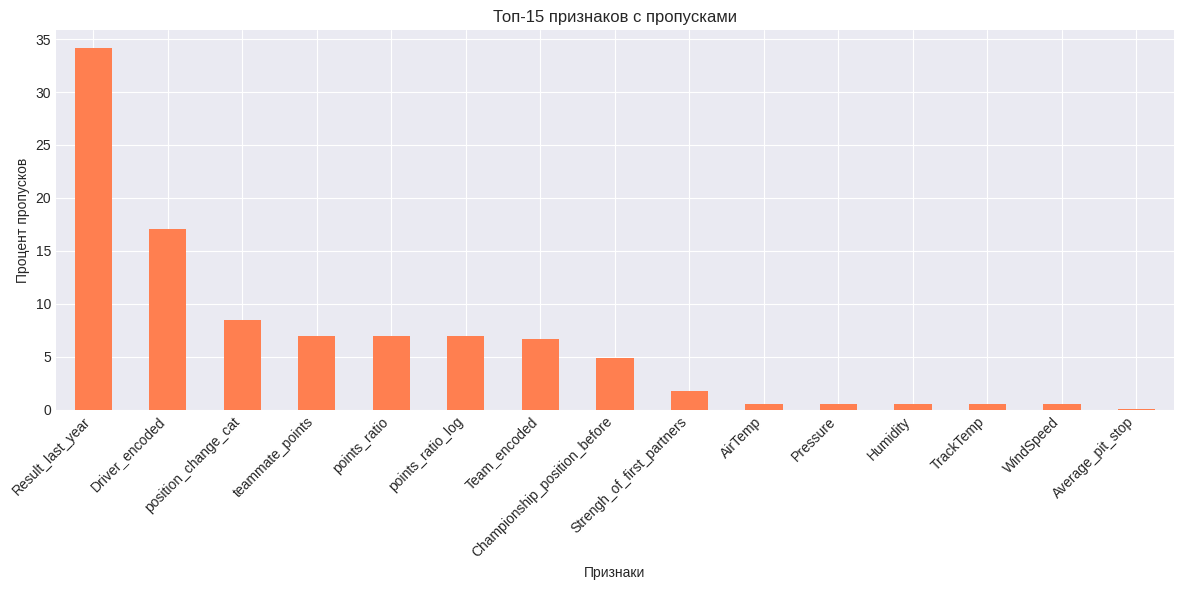

In [ ]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
missing_pct.plot(kind='bar', color='coral')
plt.xlabel('Признаки')
plt.ylabel('Процент пропусков')
plt.title('Топ-15 признаков с пропусками')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Rainfall - столько пропусков по-видимому из-за того, что пропуск означает, что дождя нет. Исправим это.

In [ ]:
df['Rainfall'] = df['Rainfall'].fillna(0)

Для Result_last_year и teammate_points такое количество пропусков вполне нормально, так как для первых гонок сезона данные значения не определены.

Корреляционный анализ


Топ-10 признаков по корреляции с результатом:
   Q                             :  0.363
   Team_encoded                  :  0.333
   Start_Position                :  0.330
   Driver_encoded                :  0.296
   Championship_position_before  :  0.289
   Encoded_driver_nations        :  0.253
   avg_season                    :  0.250
   P2                            :  0.213
   P3                            :  0.209
   P1                            :  0.205

Топ-10 признаков с отрицательной корреляцией:
   points_ratio                  : -0.229
   teammate_points               : -0.239
   Salary                        : -0.252
   Points_before_race            : -0.254
   points_ratio_log              : -0.257
   Salary_encoded                : -0.278
   Team_financial_power          : -0.293
   Is_finished                   : -0.835
   position_change               : -0.867
   Rainfall                      :    nan


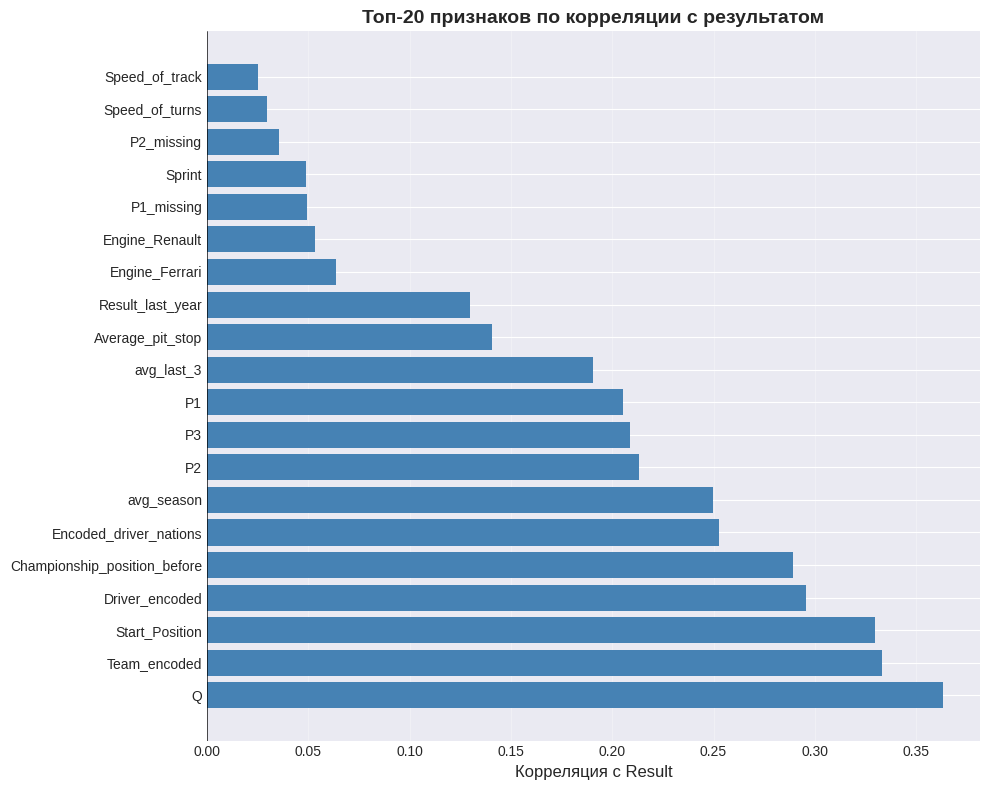

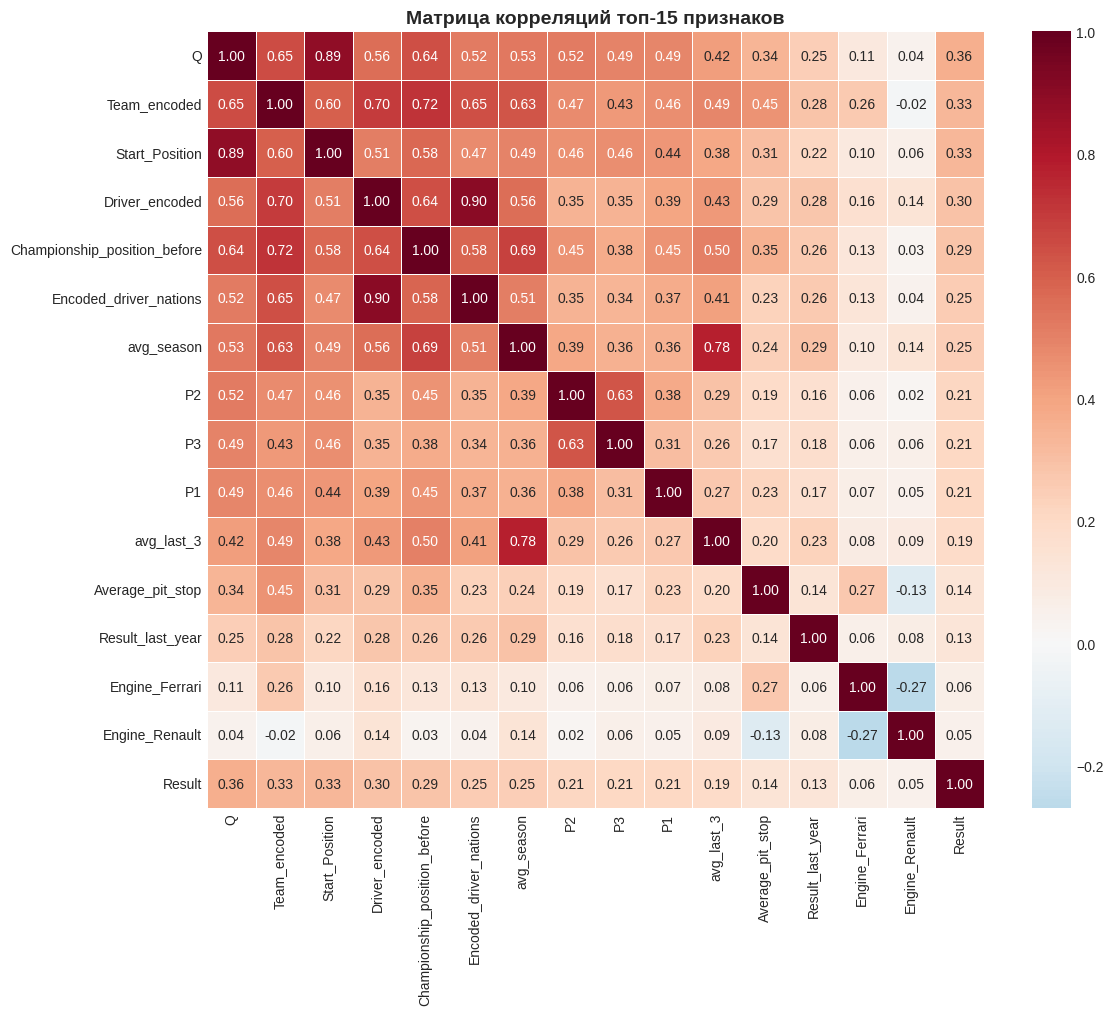

In [ ]:
exclude_features = ['Is_accident', 'Is_mechanical', 'Is_dsq'] # Признаки из будущего
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in exclude_features]
corr_with_target = df[numeric_cols].corr()['Result'].sort_values(ascending=False)

print("\nТоп-10 признаков по корреляции с результатом:")
for feat, corr in corr_with_target.head(11).items():
    if feat != 'Result':
        print(f"   {feat:30}: {corr:6.3f}")

print("\nТоп-10 признаков с отрицательной корреляцией:")
for feat, corr in corr_with_target.tail(10).items():
    if feat != 'Result':
        print(f"   {feat:30}: {corr:6.3f}")

plt.figure(figsize=(10, 8))
top_corr = corr_with_target.drop('Result').head(20)
plt.barh(range(len(top_corr)), top_corr.values, color='steelblue')
plt.yticks(range(len(top_corr)), top_corr.index)
plt.xlabel('Корреляция с Result', fontsize=12)
plt.title('Топ-20 признаков по корреляции с результатом', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
top15_features = corr_with_target.drop('Result').head(15).index.tolist()
top15_features.append('Result')
corr_matrix = df[top15_features].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 10})
plt.title('Матрица корреляций топ-15 признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Анализ изменяемости позиций гонщиков в течение в гонки

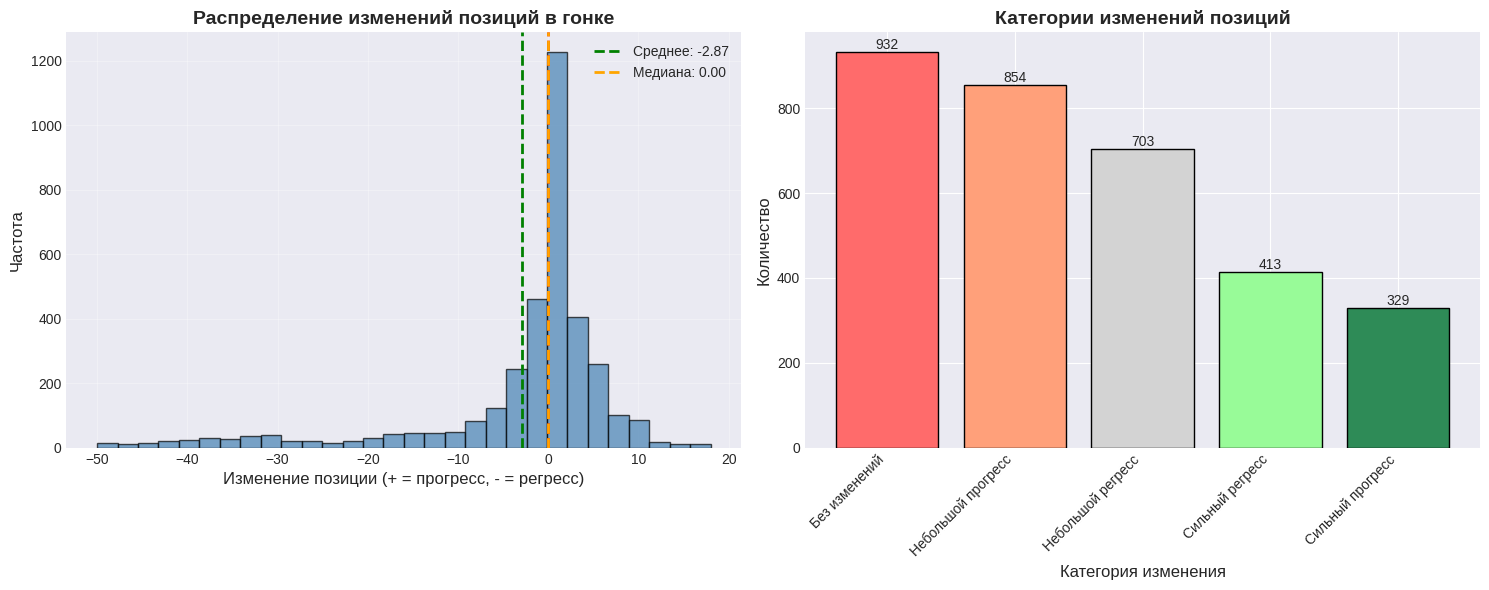

In [ ]:
df['position_change'] = df['Start_Position'] - df['Result']
df['position_change_cat'] = pd.cut(df['position_change'],
                                     bins=[-20, -5, -1, 1, 5, 20],
                                     labels=['Сильный регресс', 'Небольшой регресс',
                                             'Без изменений', 'Небольшой прогресс', 'Сильный прогресс'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(df['position_change'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Изменение позиции (+ = прогресс, - = регресс)', fontsize=12)
axes[0].set_ylabel('Частота', fontsize=12)
axes[0].set_title('Распределение изменений позиций в гонке', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

mean_val = df['position_change'].mean()
median_val = df['position_change'].median()
axes[0].axvline(x=mean_val, color='green', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:.2f}')
axes[0].axvline(x=median_val, color='orange', linestyle='--', linewidth=2, label=f'Медиана: {median_val:.2f}')
axes[0].legend()

change_counts = df['position_change_cat'].value_counts()
colors = ['#ff6b6b', '#ffa07a', '#d3d3d3', '#98fb98', '#2e8b57']
bars = axes[1].bar(change_counts.index, change_counts.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Категория изменения', fontsize=12)
axes[1].set_ylabel('Количество', fontsize=12)
axes[1].set_title('Категории изменений позиций', fontsize=14, fontweight='bold')
plt.setp(axes[1].xaxis.get_ticklabels(), rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

#Обучение первой модели по предсказанию положения гонщиков после гонки.

В начале работы для выбора наилучших признаков будем работать с моделью xgboost, так как она может обрабатывать пропуски и хорошо работает для временных рядов.

In [ ]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

feature_cols = [
    # Пилот и команда
    'Driver_encoded', 'Team_encoded', 'Encoded_driver_nations',
    'Age', 'Salary_encoded', 'Team_financial_power',
    'Strengh_of_first_partners', 'Factorys_or_not',

    # Двигатель
    'Engine_Ferrari', 'Engine_Mercedes', 'Engine_Honda', 'Engine_Renault',

    # Трасса
    'Place_encoded', 'CircleLength', 'Tire_wear', 'Speed_of_turns',
    'Downforce', 'Brake_load', 'Streets_or_not', 'Speed_of_track',
    'PitStop_losing_time', 'Quantity_of_circles', 'Quantity_of_turns',

    # Погода
    'AirTemp', 'TrackTemp', 'Humidity', 'Rainfall', 'WindSpeed',

    # Форма до гонки
    'Points_before_race', 'Championship_position_before',
    'avg_points_ratio', 'avg_last_3', 'avg_season',
    'Result_last_year',

    # Квалификация и практики
    'Q', 'Start_Position', 'Sprint',
    'P1', 'P2', 'P3',

    # Пит-стопы
    'Average_pit_stop',

    # Регламент
    'Regulation_Impact',
    'Year', 'Round',
]

target = 'Result'

In [ ]:
model_data = df.sort_values(['Year', 'Round'])
X = model_data[feature_cols]
Y = model_data[target]

Ниже используем разбиение данных на несколько фолдов для временной кросс-валидации

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
for i, (train_idx, val_idx) in enumerate(tscv.split(X)):
    train_years = model_data.iloc[train_idx]['Year'].unique()
    val_years = model_data.iloc[val_idx]['Year'].unique()
    print(f"\nFold {i+1}:")
    print(f"  Train: годы {sorted(train_years)}")
    print(f"  Val: годы {sorted(val_years)}")


Fold 1:
  Train: годы [np.int64(2018), np.int64(2019)]
  Val: годы [np.int64(2019), np.int64(2020)]

Fold 2:
  Train: годы [np.int64(2018), np.int64(2019), np.int64(2020)]
  Val: годы [np.int64(2021), np.int64(2022)]

Fold 3:
  Train: годы [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
  Val: годы [np.int64(2022), np.int64(2023)]

Fold 4:
  Train: годы [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
  Val: годы [np.int64(2023), np.int64(2024)]

Fold 5:
  Train: годы [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  Val: годы [np.int64(2024), np.int64(2025)]


In [ ]:
mae_scores = []
rmse_scores = []
r2_scores = []
models = []
feature_importance_list = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = Y.iloc[train_idx], Y.iloc[val_idx]
    model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric='mae')
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False)

    y_pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    models.append(model)
    importance = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    feature_importance_list.append(importance)

    print(f"MAE: {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2: {r2:.3f}")
    print("\nТоп-5 важных признаков:")
    print(importance.head(5).to_string(index=False))

MAE: 8.290
RMSE: 11.759
R2: 0.050

Топ-5 важных признаков:
        feature  importance
              Q    0.077731
 Engine_Ferrari    0.073470
      Tire_wear    0.039061
 Start_Position    0.032955
Factorys_or_not    0.031771
MAE: 7.319
RMSE: 10.758
R2: 0.072

Топ-5 важных признаков:
        feature  importance
              Q    0.078916
Factorys_or_not    0.041880
 Engine_Renault    0.034516
 Start_Position    0.031745
     Brake_load    0.028215
MAE: 7.030
RMSE: 10.335
R2: 0.077

Топ-5 важных признаков:
             feature  importance
                   Q    0.094404
     Factorys_or_not    0.042351
      Start_Position    0.031929
Team_financial_power    0.030684
                  P2    0.030087
MAE: 6.655
RMSE: 10.483
R2: 0.137

Топ-5 важных признаков:
             feature  importance
                   Q    0.084704
Team_financial_power    0.043743
        Team_encoded    0.035470
      Speed_of_turns    0.031154
          avg_season    0.029810
MAE: 6.982
RMSE: 10.899
R2: 0.14

#Создание более продвинутых признаков

##Признаки взаимодействий

In [1]:
data = df.copy()

NameError: name 'df' is not defined

In [ ]:
base_feats = [
    "Q", "Speed_of_track", "avg_season", "Speed_of_turns", "Start_Position", "Factorys_or_not",
    "P1", "P2", "P3","Engine_Ferrari", "Engine_Mercedes", "Engine_Honda",
]

Положение перед гонкой и результат:

In [2]:
data = data.sort_values(['Year', 'Round']).reset_index(drop=True)
data['q_x_team'] = data['Q'] * data['Team_encoded']
data['q_x_ferrari_engine'] = data['Q'] * data['Engine_Ferrari']
data['q_x_mercedes_engine'] = data['Q'] * data['Engine_Mercedes']
data['q_x_honda_engine'] = data['Q'] * data['Engine_Honda']
data['q_x_factory'] = data['Q'] * data['Factorys_or_not']
data['q_to_start_diff'] = data['Start_Position'] - data['Q']
data['practice_progress'] = data['P3'] - data['P1']
data['all_progress'] = data['Q'] - data['P1']
data['average_progress'] = data['Q'] - (data['P1'] + data['P2'] + data['P3']) / 3

data['team_q_cumsum'] = data.groupby('Team_encoded')['Q'].cumsum()
data['team_q_count'] = data.groupby('Team_encoded').cumcount() + 1
data['team_q_expanding_mean'] = (data['team_q_cumsum'] - data['Q']) / (data['team_q_count'] - 1)
data['team_q_expanding_mean'] = data['team_q_expanding_mean'].fillna(0)
data['q_vs_team_avg'] = data['Q'] - data['team_q_expanding_mean']
data = data.drop(columns=['team_q_cumsum', 'team_q_count', 'team_q_expanding_mean'])

def calculate_historical_avg(df, group_col, value_col):
    """
    Вычисляет историческое среднее для каждой строки на основе предыдущих данных
    """
    result = []
    for i in range(len(df)):
        if i == 0:
            result.append(0)
            continue
        prev_data = df.iloc[:i]
        avg_series = prev_data.groupby(group_col)[value_col].mean()
        current_key = df.iloc[i][group_col]
        result.append(avg_series.get(current_key, 0))
    return result

data['driver_avg_history'] = calculate_historical_avg(data, 'Driver_encoded', 'Result')
data['team_avg_history'] = calculate_historical_avg(data, 'Team_encoded', 'Result')
data['result_vs_team_avg'] = data['driver_avg_history'] - data['team_avg_history']
data['teammate_encoded'] = None

for team in data['Team_encoded'].unique():
    team_mask = data['Team_encoded'] == team
    for year in data['Year'].unique():
        for round_num in data['Round'].unique():
            mask = team_mask & (data['Year'] == year) & (data['Round'] == round_num)
            drivers = data.loc[mask, 'Driver_encoded'].values
            if len(drivers) == 2:
                for idx in data[mask].index:
                    if data.loc[idx, 'Driver_encoded'] == drivers[0]:
                        data.loc[idx, 'teammate_encoded'] = drivers[1]
                    else:
                        data.loc[idx, 'teammate_encoded'] = drivers[0]
data['teammate_last_q'] = 0.0

for idx in data.index:
    if pd.isna(data.loc[idx, 'teammate_encoded']):
        data.loc[idx, 'teammate_last_q'] = 0
        continue

    teammate = data.loc[idx, 'teammate_encoded']
    year = data.loc[idx, 'Year']
    round_num = data.loc[idx, 'Round']
    teammate_prev = data[
        (data['Driver_encoded'] == teammate) &
        ((data['Year'] < year) | ((data['Year'] == year) & (data['Round'] < round_num)))
    ].sort_values(['Year', 'Round'], ascending=False)

    if len(teammate_prev) > 0:
        data.loc[idx, 'teammate_last_q'] = teammate_prev.iloc[0]['Q']
    else:
        data.loc[idx, 'teammate_last_q'] = 0

data['q_gap_to_teammate'] = data['Q'] - data['teammate_last_q']
data['q_gap_to_teammate'] = data['q_gap_to_teammate'].fillna(0)
data = data.drop(columns=['teammate_encoded', 'teammate_last_q'])
data['ferrari_x_vs_team'] = data['Engine_Ferrari'] * data['result_vs_team_avg']
data['mercedes_x_vs_team'] = data['Engine_Mercedes'] * data['result_vs_team_avg']
data['redbull_x_vs_team'] = data['Team_encoded'] * data['result_vs_team_avg']
data['result_vs_team_x_q'] = data['result_vs_team_avg'] * data['Q']
data['result_vs_team_x_rain'] = data['result_vs_team_avg'] * data['Rainfall']
data['result_vs_team_x_factory'] = data['result_vs_team_avg'] * data['Factorys_or_not']

track_difficulty = (data['Tire_wear'] + data['Speed_of_turns'] + data['Brake_load']) / 3
data['form_x_difficulty'] = data['avg_points_ratio'] * track_difficulty

data['points_to_leader'] = data.groupby(['Year', 'Round'])['Points_before_race'].transform(
    lambda x: x.max() - x
)
data['championship_rank'] = data.groupby(['Year', 'Round'])['Points_before_race'].rank(
    method='dense', ascending=False
)
data['rank_x_team'] = data['championship_rank'] * data['Team_encoded']

data = data.drop(columns=['driver_avg_history', 'team_avg_history'])

NameError: name 'data' is not defined

In [ ]:
new_feats = [
    'q_x_team', 'q_x_ferrari_engine', 'q_x_mercedes_engine', 'q_x_honda_engine',
    'q_x_factory', 'q_to_start_diff', 'practice_progress', 'all_progress',
    'average_progress', 'redbull_x_vs_team', 'rank_x_team', 'form_x_difficulty',
    'q_vs_team_avg', 'ferrari_x_vs_team', 'mercedes_x_vs_team', 'result_vs_team_x_q',
    'result_vs_team_x_rain', 'result_vs_team_x_factory', 'championship_rank', 'points_to_leader',
]

In [ ]:
run_experiment(data, new_feats, )

Оставим для дальнейшего анализа redbull_x_vs_team, q_x_team, result_vs_team_x_q, points_to_leader, rank_x_team, all_progress, q_to_start_diff, form_x_difficulty, q_x_honda_engine

##Признаки относительности

In [ ]:
data['points_ratio'] = data['Points_before_race'] / (data['teammate_points'] + 1e-6)
data['points_ratio_log'] = np.log1p(data['points_ratio'])
data['points_ratio_squared'] = data['points_ratio'] ** 2
data['points_ratio_log_squared'] = data['points_ratio_log'] ** 2
data['ratio_power'] = data['points_ratio'] * data['points_ratio_squared']
data['ratio_log_power'] = data['points_ratio_log'] * data['points_ratio_log_squared']

if 'result_vs_team_avg' in data.columns:
    data['result_gap_normalized'] = data['result_vs_team_avg'] / (data['result_vs_team_avg'].std() + 1e-6)

if 'points_ratio_log' in data.columns and 'result_gap_normalized' in data.columns:
    data['meta_ratio'] = data['points_ratio_log'] / (data['result_gap_normalized'].abs() + 1)
new_feats = [
    'points_ratio',
    'points_ratio_log',
    'points_ratio_squared',
    'points_ratio_log_squared',
    'result_gap_normalized',
    'meta_ratio',
    'ratio_power',
    'ratio_log_power'
]


In [ ]:
run_experiment(data, new_feats)


МЕТРИКИ:
   R²  = -0.0736 ± 0.1010
   MAE = 7.90 ± 0.66

 Признаки по важности
   Признак                             Важность   Статус    
   ──────────────────────────────────────────────────────────
   points_ratio_log                    0.2759     Важный
   meta_ratio                          0.1952     Важный
   points_ratio_squared                0.1775     Важный
   points_ratio                        0.1653     Важный
   result_gap_normalized               0.1618     Важный
   ratio_power                         0.0236     Низкий
   points_ratio_log_squared            0.0006     Низкий
   ratio_log_power                     0.0000     Низкий


{'r2_mean': np.float64(-0.07363893211905918),
 'r2_std': np.float64(0.10104916441792951),
 'mae_mean': np.float64(7.898011442565189),
 'mae_std': np.float64(0.6596026559317414),
 'importance': {'points_ratio': np.float32(0.16528878),
  'points_ratio_log': np.float32(0.27592784),
  'points_ratio_squared': np.float32(0.1775244),
  'points_ratio_log_squared': np.float32(0.00064361014),
  'result_gap_normalized': np.float32(0.16175501),
  'meta_ratio': np.float32(0.19521907),
  'ratio_power': np.float32(0.023641279),
  'ratio_log_power': np.float32(0.0)},
 'features_used': ['points_ratio',
  'points_ratio_log',
  'points_ratio_squared',
  'points_ratio_log_squared',
  'result_gap_normalized',
  'meta_ratio',
  'ratio_power',
  'ratio_log_power']}

Оставим для дальнейшего анализа result_gap_normalized, points_ratio_log, meta_ratio, points_ratio, points_ratio_squared

##Скользящие признаки

In [ ]:
windows = [3, 5]
for w in windows:
    data[f'avg_last_{w}'] = data.groupby('Driver_encoded')['Result'].transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).mean()
    )
    data[f'best_last_{w}'] = data.groupby('Driver_encoded')['Result'].transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).min()
    )
    data[f'worst_last_{w}'] = data.groupby('Driver_encoded')['Result'].transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).max()
    )
for w in windows:
    data[f'range_last_{w}'] = data[f'worst_last_{w}'] - data[f'best_last_{w}']
data['form_acceleration'] = data['avg_last_3'] - data['avg_last_5']
data['form_volatility'] = data.groupby('Driver_encoded')['Result'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std()
)
data['consistency_vs_avg'] = data['form_volatility'] / (data['avg_last_5'] + 1)
data['improvement_vs_history'] = data['avg_last_3'] - data.groupby('Driver_encoded')['Result'].transform(
    lambda x: x.shift(1).expanding().mean()
)

new_feats = [
    'avg_last_3', 'avg_last_5', 'best_last_3', 'best_last_5',
    'worst_last_3', 'worst_last_5', 'range_last_3', 'range_last_5',
    'form_acceleration', 'form_volatility', 'consistency_vs_avg',
    'improvement_vs_history'
]

In [ ]:
run_experiment(data, new_feats)


МЕТРИКИ:
   R²  = -0.0340 ± 0.0888
   MAE = 7.77 ± 0.73

 Признаки по важности
   Признак                             Важность   Статус    
   ──────────────────────────────────────────────────────────
   best_last_5                         0.2625     Важный
   avg_last_5                          0.0809     Важный
   worst_last_5                        0.0792     Важный
   best_last_3                         0.0735     Важный
   range_last_5                        0.0703     Важный
   form_acceleration                   0.0697     Важный
   worst_last_3                        0.0658     Важный
   consistency_vs_avg                  0.0657     Важный
   range_last_3                        0.0614     Важный
   improvement_vs_history              0.0600     Важный
   form_volatility                     0.0576     Важный
   avg_last_3                          0.0533     Важный


{'r2_mean': np.float64(-0.034022036501408316),
 'r2_std': np.float64(0.08883722800139966),
 'mae_mean': np.float64(7.769325201401905),
 'mae_std': np.float64(0.728996749402303),
 'importance': {'avg_last_3': np.float32(0.053314872),
  'avg_last_5': np.float32(0.080945),
  'best_last_3': np.float32(0.073463425),
  'best_last_5': np.float32(0.26247105),
  'worst_last_3': np.float32(0.06579025),
  'worst_last_5': np.float32(0.079240166),
  'range_last_3': np.float32(0.06141553),
  'range_last_5': np.float32(0.07031462),
  'form_acceleration': np.float32(0.0696858),
  'form_volatility': np.float32(0.0576128),
  'consistency_vs_avg': np.float32(0.065709285),
  'improvement_vs_history': np.float32(0.060037233)},
 'features_used': ['avg_last_3',
  'avg_last_5',
  'best_last_3',
  'best_last_5',
  'worst_last_3',
  'worst_last_5',
  'range_last_3',
  'range_last_5',
  'form_acceleration',
  'form_volatility',
  'consistency_vs_avg',
  'improvement_vs_history']}

Оставим для дальнейшего анализа avg_last_3, form_acceleration, avg_last_5, form_volatility, range_last_5, worst_last_5, consistency_vs_avg

## Комбинации лучших признаков

In [ ]:
if all(f in data.columns for f in ['points_ratio_log', 'result_gap_normalized']):
    data['super_1'] = (
        data['points_ratio_log'] * 0.5 +
        data['result_gap_normalized'] * 0.5
    )

if all(f in data.columns for f in ['points_ratio_log', 'rank_x_team', 'avg_last_3']):
    data['super_2'] = (
        data['points_ratio_log'] * 0.3 +
        data['rank_x_team'] * 0.3 +
        data['avg_last_3'] * 0.4
    )

if all(f in data.columns for f in ['points_ratio_log', 'result_gap_normalized', 'meta_ratio']):
    data['super_3'] = (
        data['points_ratio_log'] * 0.4 +
        data['result_gap_normalized'] * 0.3 +
        data['meta_ratio'] * 0.3
    )

if all(f in data.columns for f in ['points_ratio_log', 'result_gap_normalized']):
    data['super_ratio_1'] = data['points_ratio_log'] * data['result_gap_normalized']

if all(f in data.columns for f in ['points_ratio', 'result_gap_normalized']):
    data['super_ratio_2'] = data['points_ratio'] * data['result_gap_normalized']
    data['super_ratio_2_squared'] = data['super_ratio_2'] ** 2

if 'championship_rank' in data.columns:
    data['driver_rank_composite'] = data['championship_rank'] / 20

if 'super_3' in data.columns and 'Q' in data.columns:
    data['q_x_super_form'] = data['Q'] * data['super_3']

new_feats = [
    'super_1', 'super_2', 'super_3',
    'super_ratio_1', 'super_ratio_2', 'super_ratio_2_squared',
    'pca_safe_1', 'pca_safe_2',
    'driver_rank_composite',
    'q_x_super_form'
]

In [ ]:
run_experiment(data, new_feats)


МЕТРИКИ:
   R²  = 0.0047 ± 0.0972
   MAE = 7.59 ± 0.66

 Признаки по важности
   Признак                             Важность   Статус    
   ──────────────────────────────────────────────────────────
   super_2                             0.2144     Важный
   super_ratio_2_squared               0.1547     Важный
   driver_rank_composite               0.1279     Важный
   q_x_super_form                      0.1192     Важный
   super_ratio_1                       0.1097     Важный
   super_3                             0.1010     Важный
   super_ratio_2                       0.0949     Важный
   super_1                             0.0783     Важный


{'r2_mean': np.float64(0.004745064303645163),
 'r2_std': np.float64(0.09720290727148674),
 'mae_mean': np.float64(7.589780259678963),
 'mae_std': np.float64(0.6625547489687535),
 'importance': {'super_1': np.float32(0.07828839),
  'super_2': np.float32(0.21436182),
  'super_3': np.float32(0.10096146),
  'super_ratio_1': np.float32(0.10972728),
  'super_ratio_2': np.float32(0.09489821),
  'super_ratio_2_squared': np.float32(0.15466052),
  'driver_rank_composite': np.float32(0.12787262),
  'q_x_super_form': np.float32(0.11922971)},
 'features_used': ['super_1',
  'super_2',
  'super_3',
  'super_ratio_1',
  'super_ratio_2',
  'super_ratio_2_squared',
  'driver_rank_composite',
  'q_x_super_form']}

Оставим для дальнейшего анализа super_ratio_1, super_2, super_ratio_2_squared super_3,

##Стратегические признаки для смены регламента в 2026 году

In [ ]:
if 'Team_financial_power' in data.columns and 'Year' in data.columns:
    data['relative_money'] = data.groupby('Year')['Team_financial_power'].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
    )
if 'Year' in data.columns:
    data['year_sin'] = np.sin(2 * np.pi * (data['Year'] - 2018) / 8)
    data['year_cos'] = np.cos(2 * np.pi * (data['Year'] - 2018) / 8)
if 'Factorys_or_not' in data.columns and 'Regulation_Impact' in data.columns:
    data['factory_x_reg'] = data['Factorys_or_not'] * data['Regulation_Impact']
# Производительность в 2022 - при нём была также масштабная смена регламента
if 'result_vs_team_avg' in data.columns and 'Year' in data.columns and 'Team_encoded' in data.columns:
    reg_2022 = data[data['Year'] == 2022].groupby('Team_encoded')['result_vs_team_avg'].mean()
    data['team_reg_2022_perf'] = data['Team_encoded'].map(reg_2022).fillna(0)

if 'result_vs_team_avg' in data.columns:
    data['pre_2026_form'] = data['result_vs_team_avg'] * ((data['Year'] >= 2024).astype(int))

if all(f in data.columns for f in ['Factorys_or_not', 'relative_money', 'team_reg_2022_perf']):
    data['adaptation_score'] = (
        data['Factorys_or_not'] * 0.3 +
        data['relative_money'] * 0.4 +
        data['team_reg_2022_perf'] * 0.3
    )

new_feats = [
    'relative_money', 'year_sin', 'year_cos', 'factory_x_reg',
    'team_reg_2022_perf', 'pre_2026_form', 'adaptation_score'
]

In [ ]:
run_experiment(data, new_feats)


МЕТРИКИ:
   R²  = 0.0315 ± 0.0278
   MAE = 7.59 ± 0.55

 Признаки по важности
   Признак                             Важность   Статус    
   ──────────────────────────────────────────────────────────
   relative_money                      0.5380     Важный
   adaptation_score                    0.2345     Важный
   team_reg_2022_perf                  0.0754     Важный
   year_sin                            0.0677     Важный
   year_cos                            0.0404     Средний
   factory_x_reg                       0.0377     Средний
   pre_2026_form                       0.0063     Низкий


{'r2_mean': np.float64(0.03149698227836946),
 'r2_std': np.float64(0.027752730519352294),
 'mae_mean': np.float64(7.588163459440477),
 'mae_std': np.float64(0.5479944295659056),
 'importance': {'relative_money': np.float32(0.5380319),
  'year_sin': np.float32(0.06766804),
  'year_cos': np.float32(0.040374994),
  'factory_x_reg': np.float32(0.03773749),
  'team_reg_2022_perf': np.float32(0.07539032),
  'pre_2026_form': np.float32(0.006273242),
  'adaptation_score': np.float32(0.23452409)},
 'features_used': ['relative_money',
  'year_sin',
  'year_cos',
  'factory_x_reg',
  'team_reg_2022_perf',
  'pre_2026_form',
  'adaptation_score']}

Оставим для дальнейшего анализа relative_money, year_sin, year_cos,team_reg_2022_perf, adaptation_score

## Признаки погоды и трассы

In [ ]:
# Погодные
data['wind_x_temp'] = data['WindSpeed'] * data['AirTemp']
data['wind_x_humidity'] = data['WindSpeed'] * data['Humidity']
data['temp_x_humidity'] = data['AirTemp'] * data['Humidity']
data['weather_stress'] = data['TrackTemp'] * data['Humidity'] / 100
data['temp_gap'] = data['TrackTemp'] - data['AirTemp']

# Трассовые
data['speed_x_turns'] = data['Speed_of_track'] * data['Quantity_of_turns']
data['speed_x_wear'] = data['Speed_of_track'] * data['Tire_wear']
data['turns_x_wear'] = data['Quantity_of_turns'] * data['Tire_wear']
data['downforce_x_speed'] = data['Downforce'] * data['Speed_of_track']

# П×Т
data['wind_x_speed'] = data['WindSpeed'] * data['Speed_of_track']
data['wind_x_turns'] = data['WindSpeed'] * data['Quantity_of_turns']
data['temp_x_speed'] = data['AirTemp'] * data['Speed_of_track']

# П×Баз
data['wind_x_q'] = data['WindSpeed'] * data['Q']
data['temp_x_q'] = data['AirTemp'] * data['Q']
data['wind_x_start'] = data['WindSpeed'] * data['Start_Position']

# Т×Баз
data['speed_x_q'] = data['Speed_of_track'] * data['Q']
data['turns_x_q'] = data['Quantity_of_turns'] * data['Q']
data['wear_x_q'] = data['Tire_wear'] * data['Q']

# Тройные
data['wind_x_temp_x_q'] = data['WindSpeed'] * data['AirTemp'] * data['Q']
data['wind_x_speed_x_q'] = data['WindSpeed'] * data['Speed_of_track'] * data['Q']
data['wind_x_turns_x_q'] = data['WindSpeed'] * data['Quantity_of_turns'] * data['Q']
data['wind_x_temp_x_points'] = data['WindSpeed'] * data['AirTemp'] * data['points_ratio_log']

# Квадратичные
data['wind_speed_squared'] = data['WindSpeed'] ** 2
data['wind_x_temp_squared'] = (data['WindSpeed'] * data['AirTemp']) ** 2
data['wind_x_speed_squared'] = (data['WindSpeed'] * data['Speed_of_track']) ** 2

# Отношения
data['wind_temp_ratio'] = data['WindSpeed'] / (data['AirTemp'] + 1)
data['wind_humidity_ratio'] = data['WindSpeed'] / (data['Humidity'] + 1)
data['temp_humidity_ratio'] = data['AirTemp'] / (data['Humidity'] + 1)
data['track_air_ratio'] = data['TrackTemp'] / (data['AirTemp'] + 1)
data['wind_pressure_ratio'] = data['WindSpeed'] / (data['Pressure'] + 1)

# П×Время
if 'year_sin' in data.columns:
    data['wind_x_year_sin'] = data['WindSpeed'] * data['year_sin']
    data['wind_x_year_cos'] = data['WindSpeed'] * data['year_cos']
    data['temp_x_year_sin'] = data['AirTemp'] * data['year_sin']

# П×Команда
data['wind_x_factory'] = data['WindSpeed'] * data['Factorys_or_not']
data['wind_x_team_encoded'] = data['WindSpeed'] * data['Team_encoded']
data['temp_x_factory'] = data['AirTemp'] * data['Factorys_or_not']
data['wind_x_engine_ferrari'] = data['WindSpeed'] * data['Engine_Ferrari']
data['wind_x_engine_mercedes'] = data['WindSpeed'] * data['Engine_Mercedes']

In [ ]:
all_new_features = [
    'wind_x_temp', 'wind_x_humidity', 'temp_x_humidity', 'weather_stress', 'temp_gap',
    'speed_x_turns', 'speed_x_wear', 'turns_x_wear', 'downforce_x_speed',
    'wind_x_speed', 'wind_x_turns', 'temp_x_speed',
    'wind_x_q', 'temp_x_q', 'wind_x_start',
    'speed_x_q', 'turns_x_q', 'wear_x_q',
    'wind_x_temp_x_q', 'wind_x_speed_x_q', 'wind_x_turns_x_q', 'wind_x_temp_x_points',
    'wind_speed_squared', 'wind_x_temp_squared', 'wind_x_speed_squared',
    'wind_temp_ratio', 'wind_humidity_ratio', 'temp_humidity_ratio', 'track_air_ratio', 'wind_pressure_ratio',
    'wind_x_year_sin', 'wind_x_year_cos', 'temp_x_year_sin',
    'wind_x_factory', 'wind_x_team_encoded', 'temp_x_factory', 'wind_x_engine_ferrari', 'wind_x_engine_mercedes'
]

In [ ]:
run_experiment(data, all_new_features)


МЕТРИКИ:
   R²  = 0.0536 ± 0.0602
   MAE = 7.40 ± 0.50

 Признаки по важности
   Признак                             Важность   Статус    
   ──────────────────────────────────────────────────────────
   wear_x_q                            0.0602     Важный
   speed_x_q                           0.0468     Средний
   temp_humidity_ratio                 0.0457     Средний
   wind_x_speed                        0.0389     Средний
   wind_x_temp_x_q                     0.0367     Средний
   wind_temp_ratio                     0.0324     Средний
   wind_x_year_cos                     0.0307     Средний
   temp_x_factory                      0.0301     Средний
   wind_x_speed_x_q                    0.0293     Низкий
   wind_x_start                        0.0286     Низкий
   wind_humidity_ratio                 0.0281     Низкий
   track_air_ratio                     0.0278     Низкий
   temp_gap                            0.0276     Низкий
   turns_x_q                           0.0275     

{'r2_mean': np.float64(0.0535904423880454),
 'r2_std': np.float64(0.06023913543931211),
 'mae_mean': np.float64(7.403704095426465),
 'mae_std': np.float64(0.49745885431640585),
 'importance': {'wind_x_temp': np.float32(0.01388101),
  'wind_x_humidity': np.float32(0.019058013),
  'temp_x_humidity': np.float32(0.023790859),
  'weather_stress': np.float32(0.021510655),
  'temp_gap': np.float32(0.0275743),
  'speed_x_turns': np.float32(0.026846085),
  'speed_x_wear': np.float32(0.016706172),
  'turns_x_wear': np.float32(0.025335025),
  'downforce_x_speed': np.float32(0.012552345),
  'wind_x_speed': np.float32(0.038870625),
  'wind_x_turns': np.float32(0.022397812),
  'temp_x_speed': np.float32(0.01698488),
  'wind_x_q': np.float32(0.022957325),
  'temp_x_q': np.float32(0.02323022),
  'wind_x_start': np.float32(0.028637296),
  'speed_x_q': np.float32(0.046804756),
  'turns_x_q': np.float32(0.027470848),
  'wear_x_q': np.float32(0.060246915),
  'wind_x_temp_x_q': np.float32(0.036707528),
  '

In [ ]:
weather_and_track_feats = [
    'wind_x_temp_x_points', 'temp_humidity_ratio', 'speed_x_q', 'wear_x_q', 'wind_x_temp_x_q',
    'temp_x_factory', 'wind_humidity_ratio', 'wind_x_speed_x_q', 'turns_x_q', 'wind_x_humidity',
]

Оставим для дальнейшего анализа wind_x_temp_x_points, temp_humidity_ratio, speed_x_q, wear_x_q, wind_x_temp_x_q, temp_x_factory, wind_humidity_ratio, wind_x_speed_x_q, turns_x_q, wind_x_humidity.

 ## Незадействоанные признаки со слабой корреляцией с целевой переменной

In [ ]:
data['sprint_x_q'] = data['Sprint'] * data['Q']
data['sprint_x_start'] = data['Sprint'] * data['Start_Position']
data['sprint_x_points_log'] = data['Sprint'] * data['points_ratio_log']
data['sprint_x_team'] = data['Sprint'] * data['Team_encoded']
data['sprint_x_factory'] = data['Sprint'] * data['Factorys_or_not']
data['sprint_x_wind'] = data['Sprint'] * data['WindSpeed']
data['sprint_x_temp'] = data['Sprint'] * data['AirTemp']
data['sprint_x_speed_track'] = data['Sprint'] * data['Speed_of_track']
data['sprint_x_turns'] = data['Sprint'] * data['Quantity_of_turns']
data['sprint_x_street'] = data['Sprint'] * data['Streets_or_not']
data['sprint_x_street_x_q'] = data['Sprint'] * data['Streets_or_not'] * data['Q']
data['sprint_x_street_x_team'] = data['Sprint'] * data['Streets_or_not'] * data['Team_encoded']

new_feats_group1 = [
    'sprint_x_q', 'sprint_x_start', 'sprint_x_points_log', 'sprint_x_team',
    'sprint_x_factory', 'sprint_x_wind', 'sprint_x_temp', 'sprint_x_speed_track',
    'sprint_x_turns', 'sprint_x_street', 'sprint_x_street_x_q', 'sprint_x_street_x_team'
]

In [ ]:
run_experiment(data, new_feats_group1)


МЕТРИКИ:
   R²  = -0.0854 ± 0.0847
   MAE = 8.21 ± 0.25

 Признаки по важности
   Признак                             Важность   Статус    
   ──────────────────────────────────────────────────────────
   sprint_x_team                       0.4422     Важный
   sprint_x_temp                       0.0858     Важный
   sprint_x_turns                      0.0768     Важный
   sprint_x_wind                       0.0624     Важный
   sprint_x_factory                    0.0590     Важный
   sprint_x_speed_track                0.0520     Важный
   sprint_x_points_log                 0.0510     Важный
   sprint_x_q                          0.0491     Средний
   sprint_x_street_x_team              0.0411     Средний
   sprint_x_street                     0.0345     Средний
   sprint_x_start                      0.0300     Средний
   sprint_x_street_x_q                 0.0163     Низкий


{'r2_mean': np.float64(-0.08543157346229821),
 'r2_std': np.float64(0.08466546586220793),
 'mae_mean': np.float64(8.207501386578391),
 'mae_std': np.float64(0.24507836497240823),
 'importance': {'sprint_x_q': np.float32(0.049107444),
  'sprint_x_start': np.float32(0.030040586),
  'sprint_x_points_log': np.float32(0.050952185),
  'sprint_x_team': np.float32(0.44215184),
  'sprint_x_factory': np.float32(0.058975417),
  'sprint_x_wind': np.float32(0.062396396),
  'sprint_x_temp': np.float32(0.08576037),
  'sprint_x_speed_track': np.float32(0.051967204),
  'sprint_x_turns': np.float32(0.07675669),
  'sprint_x_street': np.float32(0.034473766),
  'sprint_x_street_x_q': np.float32(0.016345285),
  'sprint_x_street_x_team': np.float32(0.041072834)},
 'features_used': ['sprint_x_q',
  'sprint_x_start',
  'sprint_x_points_log',
  'sprint_x_team',
  'sprint_x_factory',
  'sprint_x_wind',
  'sprint_x_temp',
  'sprint_x_speed_track',
  'sprint_x_turns',
  'sprint_x_street',
  'sprint_x_street_x_q',


In [ ]:
data['street_x_q'] = data['Streets_or_not'] * data['Q']
data['street_x_start'] = data['Streets_or_not'] * data['Start_Position']
data['street_x_points_log'] = data['Streets_or_not'] * data['points_ratio_log']
data['street_x_team'] = data['Streets_or_not'] * data['Team_encoded']
data['street_x_factory'] = data['Streets_or_not'] * data['Factorys_or_not']
data['street_x_wind'] = data['Streets_or_not'] * data['WindSpeed']
data['street_x_temp'] = data['Streets_or_not'] * data['AirTemp']
data['street_x_speed_track'] = data['Streets_or_not'] * data['Speed_of_track']
data['street_x_turns'] = data['Streets_or_not'] * data['Quantity_of_turns']
data['street_x_wear'] = data['Streets_or_not'] * data['Tire_wear']

data['downforce_x_q'] = data['Downforce'] * data['Q']
data['downforce_x_start'] = data['Downforce'] * data['Start_Position']
data['downforce_x_points_log'] = data['Downforce'] * data['points_ratio_log']
data['downforce_x_team'] = data['Downforce'] * data['Team_encoded']
data['downforce_x_wind'] = data['Downforce'] * data['WindSpeed']
data['downforce_x_temp'] = data['Downforce'] * data['AirTemp']
data['downforce_x_speed_track'] = data['Downforce'] * data['Speed_of_track']
data['downforce_x_turns'] = data['Downforce'] * data['Quantity_of_turns']
data['downforce_x_wear'] = data['Downforce'] * data['Tire_wear']
data['downforce_x_street'] = data['Downforce'] * data['Streets_or_not']

data['brake_x_q'] = data['Brake_load'] * data['Q']
data['brake_x_start'] = data['Brake_load'] * data['Start_Position']
data['brake_x_points_log'] = data['Brake_load'] * data['points_ratio_log']
data['brake_x_team'] = data['Brake_load'] * data['Team_encoded']
data['brake_x_wind'] = data['Brake_load'] * data['WindSpeed']
data['brake_x_temp'] = data['Brake_load'] * data['AirTemp']
data['brake_x_speed_track'] = data['Brake_load'] * data['Speed_of_track']
data['brake_x_turns'] = data['Brake_load'] * data['Quantity_of_turns']
data['brake_x_wear'] = data['Brake_load'] * data['Tire_wear']
data['brake_x_street'] = data['Brake_load'] * data['Streets_or_not']

data['track_speed_x_points_log'] = data['Speed_of_track'] * data['points_ratio_log']
data['track_speed_x_team'] = data['Speed_of_track'] * data['Team_encoded']
data['track_speed_x_factory'] = data['Speed_of_track'] * data['Factorys_or_not']

new_feats_group2 = [
    'street_x_q', 'street_x_start', 'street_x_points_log', 'street_x_team',
    'street_x_factory', 'street_x_wind', 'street_x_temp', 'street_x_speed_track',
    'street_x_turns', 'street_x_wear',
    'downforce_x_q', 'downforce_x_start', 'downforce_x_points_log', 'downforce_x_team',
    'downforce_x_wind', 'downforce_x_temp', 'downforce_x_speed_track', 'downforce_x_turns',
    'downforce_x_wear', 'downforce_x_street',
    'brake_x_q', 'brake_x_start', 'brake_x_points_log', 'brake_x_team',
    'brake_x_wind', 'brake_x_temp', 'brake_x_speed_track', 'brake_x_turns',
    'brake_x_wear', 'brake_x_street',
    'track_speed_x_points_log', 'track_speed_x_team', 'track_speed_x_factory'
]

In [ ]:
run_experiment(data, new_feats_group2)


МЕТРИКИ:
   R²  = 0.0255 ± 0.0435
   MAE = 7.48 ± 0.55

 Признаки по важности
   Признак                             Важность   Статус    
   ──────────────────────────────────────────────────────────
   brake_x_q                           0.0748     Важный
   brake_x_start                       0.0548     Важный
   brake_x_turns                       0.0510     Важный
   downforce_x_q                       0.0490     Средний
   track_speed_x_team                  0.0479     Средний
   downforce_x_team                    0.0443     Средний
   brake_x_team                        0.0435     Средний
   track_speed_x_factory               0.0432     Средний
   brake_x_points_log                  0.0386     Средний
   brake_x_temp                        0.0377     Средний
   downforce_x_turns                   0.0364     Средний
   track_speed_x_points_log            0.0343     Средний
   street_x_start                      0.0338     Средний
   downforce_x_points_log              0.0336  

{'r2_mean': np.float64(0.025484506617148028),
 'r2_std': np.float64(0.043485877106742066),
 'mae_mean': np.float64(7.480682790742135),
 'mae_std': np.float64(0.5514151996977695),
 'importance': {'street_x_q': np.float32(0.022080239),
  'street_x_start': np.float32(0.033839032),
  'street_x_points_log': np.float32(0.020894084),
  'street_x_team': np.float32(0.01992066),
  'street_x_factory': np.float32(0.028752524),
  'street_x_wind': np.float32(0.02219864),
  'street_x_temp': np.float32(0.018399464),
  'street_x_speed_track': np.float32(0.022496542),
  'street_x_turns': np.float32(0.0069387243),
  'street_x_wear': np.float32(0.010912839),
  'downforce_x_q': np.float32(0.048989214),
  'downforce_x_start': np.float32(0.03123213),
  'downforce_x_points_log': np.float32(0.033580236),
  'downforce_x_team': np.float32(0.044349972),
  'downforce_x_wind': np.float32(0.027997222),
  'downforce_x_temp': np.float32(0.029320344),
  'downforce_x_speed_track': np.float32(0.028121788),
  'downforce_x

In [ ]:
data['age_x_q'] = data['Age'] * data['Q']
data['age_x_start'] = data['Age'] * data['Start_Position']
data['age_x_points_log'] = data['Age'] * data['points_ratio_log']
data['age_x_team'] = data['Age'] * data['Team_encoded']
data['age_x_experience'] = data['Age'] * data['avg_last_3']
data['age_x_salary'] = data['Age'] * data['Salary']
data['age_x_factory'] = data['Age'] * data['Factorys_or_not']
data['age_x_wind'] = data['Age'] * data['WindSpeed']
data['age_x_temp'] = data['Age'] * data['AirTemp']

data['salary_x_q'] = data['Salary'] * data['Q']
data['salary_x_start'] = data['Salary'] * data['Start_Position']
data['salary_x_points_log'] = data['Salary'] * data['points_ratio_log']
data['salary_x_team'] = data['Salary'] * data['Team_encoded']
data['salary_x_factory'] = data['Salary'] * data['Factorys_or_not']
data['salary_x_age'] = data['Salary'] * data['Age']
data['salary_x_experience'] = data['Salary'] * data['avg_last_3']
data['salary_x_wind'] = data['Salary'] * data['WindSpeed']
data['salary_x_temp'] = data['Salary'] * data['AirTemp']

data['age_x_q_x_points'] = data['Age'] * data['Q'] * data['points_ratio_log']
data['age_x_salary_x_team'] = data['Age'] * data['Salary'] * data['Team_encoded']
data['age_x_wind_x_temp'] = data['Age'] * data['WindSpeed'] * data['AirTemp']

new_feats_group3 = [
    'age_x_q', 'age_x_start', 'age_x_points_log', 'age_x_team',
    'age_x_experience', 'age_x_salary', 'age_x_factory', 'age_x_wind', 'age_x_temp',
    'salary_x_q', 'salary_x_start', 'salary_x_points_log', 'salary_x_team',
    'salary_x_factory', 'salary_x_age', 'salary_x_experience', 'salary_x_wind', 'salary_x_temp',
    'age_x_q_x_points', 'age_x_salary_x_team', 'age_x_wind_x_temp'
]

In [ ]:
run_experiment(data, new_feats_group3)


МЕТРИКИ:
   R²  = -0.0194 ± 0.1417
   MAE = 7.80 ± 0.96

 Признаки по важности
   Признак                             Важность   Статус    
   ──────────────────────────────────────────────────────────
   age_x_q                             0.1136     Важный
   age_x_salary_x_team                 0.0754     Важный
   salary_x_factory                    0.0613     Важный
   age_x_team                          0.0593     Важный
   age_x_factory                       0.0559     Важный
   salary_x_temp                       0.0537     Важный
   age_x_salary                        0.0521     Важный
   age_x_q_x_points                    0.0473     Средний
   salary_x_wind                       0.0453     Средний
   age_x_start                         0.0442     Средний
   age_x_experience                    0.0424     Средний
   salary_x_points_log                 0.0422     Средний
   age_x_temp                          0.0418     Средний
   age_x_wind_x_temp                   0.0414     

{'r2_mean': np.float64(-0.01937917801999889),
 'r2_std': np.float64(0.14172010381009784),
 'mae_mean': np.float64(7.797876929890895),
 'mae_std': np.float64(0.9626927423743454),
 'importance': {'age_x_q': np.float32(0.11361933),
  'age_x_start': np.float32(0.04422798),
  'age_x_points_log': np.float32(0.034642853),
  'age_x_team': np.float32(0.05931715),
  'age_x_experience': np.float32(0.0423956),
  'age_x_salary': np.float32(0.05214561),
  'age_x_factory': np.float32(0.05592323),
  'age_x_wind': np.float32(0.038918745),
  'age_x_temp': np.float32(0.041826263),
  'salary_x_q': np.float32(0.039881315),
  'salary_x_start': np.float32(0.040032983),
  'salary_x_points_log': np.float32(0.042198308),
  'salary_x_team': np.float32(0.035617832),
  'salary_x_factory': np.float32(0.061291166),
  'salary_x_age': np.float32(0.0),
  'salary_x_experience': np.float32(0.03486023),
  'salary_x_wind': np.float32(0.045287356),
  'salary_x_temp': np.float32(0.053702146),
  'age_x_q_x_points': np.float32

In [ ]:
data['pitstop_x_q'] = data['PitStop_losing_time'] * data['Q']
data['pitstop_x_start'] = data['PitStop_losing_time'] * data['Start_Position']
data['pitstop_x_points_log'] = data['PitStop_losing_time'] * data['points_ratio_log']
data['pitstop_x_team'] = data['PitStop_losing_time'] * data['Team_encoded']
data['pitstop_x_factory'] = data['PitStop_losing_time'] * data['Factorys_or_not']
data['pitstop_x_wind'] = data['PitStop_losing_time'] * data['WindSpeed']
data['pitstop_x_temp'] = data['PitStop_losing_time'] * data['AirTemp']
data['pitstop_x_speed_track'] = data['PitStop_losing_time'] * data['Speed_of_track']
data['pitstop_x_turns'] = data['PitStop_losing_time'] * data['Quantity_of_turns']
data['pitstop_x_wear'] = data['PitStop_losing_time'] * data['Tire_wear']

data['avg_pit_x_q'] = data['Average_pit_stop'] * data['Q']
data['avg_pit_x_start'] = data['Average_pit_stop'] * data['Start_Position']
data['avg_pit_x_points_log'] = data['Average_pit_stop'] * data['points_ratio_log']
data['avg_pit_x_team'] = data['Average_pit_stop'] * data['Team_encoded']
data['avg_pit_x_factory'] = data['Average_pit_stop'] * data['Factorys_or_not']
data['avg_pit_x_wind'] = data['Average_pit_stop'] * data['WindSpeed']
data['avg_pit_x_temp'] = data['Average_pit_stop'] * data['AirTemp']
data['avg_pit_x_speed_track'] = data['Average_pit_stop'] * data['Speed_of_track']
data['avg_pit_x_turns'] = data['Average_pit_stop'] * data['Quantity_of_turns']

data['pitstop_to_q_ratio'] = data['PitStop_losing_time'] / (data['Q'] + 1)
data['pitstop_to_speed_ratio'] = data['PitStop_losing_time'] / (data['Speed_of_track'] + 1)
data['pitstop_to_age_ratio'] = data['PitStop_losing_time'] / (data['Age'] + 1)

data['pitstop_x_q_x_team'] = data['PitStop_losing_time'] * data['Q'] * data['Team_encoded']
data['pitstop_x_wind_x_temp'] = data['PitStop_losing_time'] * data['WindSpeed'] * data['AirTemp']
data['pitstop_x_speed_x_turns'] = data['PitStop_losing_time'] * data['Speed_of_track'] * data['Quantity_of_turns']

new_feats_group4 = [
    'pitstop_x_q', 'pitstop_x_start', 'pitstop_x_points_log', 'pitstop_x_team',
    'pitstop_x_factory', 'pitstop_x_wind', 'pitstop_x_temp', 'pitstop_x_speed_track',
    'pitstop_x_turns', 'pitstop_x_wear',
    'avg_pit_x_q', 'avg_pit_x_start', 'avg_pit_x_points_log', 'avg_pit_x_team',
    'avg_pit_x_factory', 'avg_pit_x_wind', 'avg_pit_x_temp', 'avg_pit_x_speed_track',
    'avg_pit_x_turns',
    'pitstop_to_q_ratio', 'pitstop_to_speed_ratio', 'pitstop_to_age_ratio',
    'pitstop_x_q_x_team', 'pitstop_x_wind_x_temp', 'pitstop_x_speed_x_turns'
]

In [ ]:
run_experiment(data,new_feats_group4)


МЕТРИКИ:
   R²  = -0.0461 ± 0.1404
   MAE = 8.02 ± 0.96

 Признаки по важности
   Признак                             Важность   Статус    
   ──────────────────────────────────────────────────────────
   avg_pit_x_q                         0.1442     Важный
   avg_pit_x_factory                   0.0541     Важный
   pitstop_x_speed_track               0.0538     Важный
   pitstop_to_speed_ratio              0.0457     Средний
   avg_pit_x_start                     0.0450     Средний
   avg_pit_x_team                      0.0423     Средний
   avg_pit_x_wind                      0.0404     Средний
   avg_pit_x_turns                     0.0388     Средний
   avg_pit_x_temp                      0.0381     Средний
   avg_pit_x_points_log                0.0376     Средний
   avg_pit_x_speed_track               0.0370     Средний
   pitstop_x_q_x_team                  0.0363     Средний
   pitstop_x_points_log                0.0350     Средний
   pitstop_x_temp                      0.0340 

{'r2_mean': np.float64(-0.04610109978126222),
 'r2_std': np.float64(0.14035298111426894),
 'mae_mean': np.float64(8.016409507749843),
 'mae_std': np.float64(0.964644142273626),
 'importance': {'pitstop_x_q': np.float32(0.01813056),
  'pitstop_x_start': np.float32(0.025068844),
  'pitstop_x_points_log': np.float32(0.03503178),
  'pitstop_x_team': np.float32(0.02468104),
  'pitstop_x_factory': np.float32(0.029830843),
  'pitstop_x_wind': np.float32(0.029636923),
  'pitstop_x_temp': np.float32(0.03401636),
  'pitstop_x_speed_track': np.float32(0.053780936),
  'pitstop_x_turns': np.float32(0.033712596),
  'pitstop_x_wear': np.float32(0.031009372),
  'avg_pit_x_q': np.float32(0.14418258),
  'avg_pit_x_start': np.float32(0.04499818),
  'avg_pit_x_points_log': np.float32(0.037588272),
  'avg_pit_x_team': np.float32(0.04226168),
  'avg_pit_x_factory': np.float32(0.054138087),
  'avg_pit_x_wind': np.float32(0.04035033),
  'avg_pit_x_temp': np.float32(0.038123127),
  'avg_pit_x_speed_track': np.

In [ ]:
data['temp_x_start'] = data['AirTemp'] * data['Start_Position']
data['temp_x_team'] = data['AirTemp'] * data['Team_encoded']
data['temp_x_points_log'] = data['AirTemp'] * data['points_ratio_log']
data['temp_x_age'] = data['AirTemp'] * data['Age']
data['temp_x_salary'] = data['AirTemp'] * data['Salary']
data['temp_x_pitstop'] = data['AirTemp'] * data['Average_pit_stop']

data['tracktemp_x_q'] = data['TrackTemp'] * data['Q']
data['tracktemp_x_start'] = data['TrackTemp'] * data['Start_Position']
data['tracktemp_x_points_log'] = data['TrackTemp'] * data['points_ratio_log']
data['tracktemp_x_team'] = data['TrackTemp'] * data['Team_encoded']
data['tracktemp_x_wind'] = data['TrackTemp'] * data['WindSpeed']
data['tracktemp_x_age'] = data['TrackTemp'] * data['Age']
data['tracktemp_x_salary'] = data['TrackTemp'] * data['Salary']

data['temp_gap_x_q'] = (data['TrackTemp'] - data['AirTemp']) * data['Q']
data['temp_gap_x_points'] = (data['TrackTemp'] - data['AirTemp']) * data['points_ratio_log']
data['temp_gap_x_team'] = (data['TrackTemp'] - data['AirTemp']) * data['Team_encoded']

new_feats_group5 = [
    'temp_x_start', 'temp_x_team', 'temp_x_points_log', 'temp_x_age',
    'temp_x_salary', 'temp_x_pitstop',
    'tracktemp_x_q', 'tracktemp_x_start', 'tracktemp_x_points_log', 'tracktemp_x_team',
    'tracktemp_x_wind', 'tracktemp_x_age', 'tracktemp_x_salary',
    'temp_gap_x_q', 'temp_gap_x_points', 'temp_gap_x_team'
]

In [ ]:
run_experiment(data, new_feats_group5)


МЕТРИКИ:
   R²  = -0.0346 ± 0.1234
   MAE = 7.81 ± 0.98

 Признаки по важности
   Признак                             Важность   Статус    
   ──────────────────────────────────────────────────────────
   tracktemp_x_salary                  0.1153     Важный
   tracktemp_x_q                       0.0934     Важный
   temp_gap_x_q                        0.0675     Важный
   temp_x_salary                       0.0607     Важный
   tracktemp_x_points_log              0.0606     Важный
   temp_x_pitstop                      0.0596     Важный
   temp_x_age                          0.0585     Важный
   tracktemp_x_team                    0.0584     Важный
   tracktemp_x_age                     0.0581     Важный
   tracktemp_x_start                   0.0580     Важный
   temp_gap_x_points                   0.0548     Важный
   tracktemp_x_wind                    0.0546     Важный
   temp_x_team                         0.0514     Важный
   temp_x_points_log                   0.0510     Важный

{'r2_mean': np.float64(-0.034618591751908845),
 'r2_std': np.float64(0.12337861159806897),
 'mae_mean': np.float64(7.812018477412307),
 'mae_std': np.float64(0.9848451354884542),
 'importance': {'temp_x_start': np.float32(0.04928117),
  'temp_x_team': np.float32(0.051402837),
  'temp_x_points_log': np.float32(0.05100758),
  'temp_x_age': np.float32(0.058535635),
  'temp_x_salary': np.float32(0.060742594),
  'temp_x_pitstop': np.float32(0.059598166),
  'tracktemp_x_q': np.float32(0.0934176),
  'tracktemp_x_start': np.float32(0.057991207),
  'tracktemp_x_points_log': np.float32(0.06061291),
  'tracktemp_x_team': np.float32(0.058400046),
  'tracktemp_x_wind': np.float32(0.054589383),
  'tracktemp_x_age': np.float32(0.058146846),
  'tracktemp_x_salary': np.float32(0.11530483),
  'temp_gap_x_q': np.float32(0.067544065),
  'temp_gap_x_points': np.float32(0.05484564),
  'temp_gap_x_team': np.float32(0.04857952)},
 'features_used': ['temp_x_start',
  'temp_x_team',
  'temp_x_points_log',
  'te

Оставим для анализа следующие признаки:

In [ ]:
additional_feats = [
    # SPRINT комбинации
    'sprint_x_turns',
    'sprint_x_temp',
    'sprint_x_points_log',
    'sprint_x_wind',
    'sprint_x_team',
    'sprint_x_factory',

    # Характеристики трассы
    'track_speed_x_points_log',
    'track_speed_x_team',
    'track_speed_x_factory',

    # Зп и Возраст
    'salary_x_points_log',
    'age_x_points_log',

    # Пит-стопы
    'avg_pit_x_points_log',
    'avg_pit_x_q',
    'pitstop_to_speed_ratio',
    'avg_pit_x_team',
    'pitstop_x_turns',

    # Температура
    'tracktemp_x_points_log',
    'temp_gap_x_points',
    'temp_x_points_log',
    'tracktemp_x_salary',
    'tracktemp_x_q'
]


In [ ]:
def run_experiment(data, feature_cols, n_splits=5):
    valid_cols = [col for col in feature_cols if col in data.columns]
    X = data[valid_cols].copy()
    y = data[target].copy()

    tscv = TimeSeriesSplit(n_splits=n_splits)

    r2_scores = []
    mae_scores = []
    importances = []

    fold = 1
    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBRegressor(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            random_state=42,
            verbosity=0
        )
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        y_pred = model.predict(X_val)

        r2_scores.append(r2_score(y_val, y_pred))
        mae_scores.append(mean_absolute_error(y_val, y_pred))
        importances.append(model.feature_importances_)
        fold += 1
    avg_r2 = np.mean(r2_scores)
    avg_mae = np.mean(mae_scores)
    std_r2 = np.std(r2_scores)
    std_mae = np.std(mae_scores)

    avg_importance = np.mean(importances, axis=0)
    importance_dict = dict(zip(valid_cols, avg_importance))
    sorted_importance = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

    improvement = ""
    if 'result_base' in globals():
        improvement = f" (Δ{avg_r2 - result_base['r2_mean']:+.3f})"

    print(f"\nМЕТРИКИ:")
    print(f"   R²  = {avg_r2:.4f} ± {std_r2:.4f}{improvement}")
    print(f"   MAE = {avg_mae:.2f} ± {std_mae:.2f}")

    # Топ-10 признаков
    print(f"\n Признаки по важности")
    print(f"   {'Признак':<35} {'Важность':<10} {'Статус':<10}")
    print(f"   {'─'*58}")

    for feat, imp in sorted_importance[:]:
        if imp > 0.05:
            status = "Важный"
        elif imp > 0.03:
            status = "Средний"
        else:
            status = "Низкий"

        print(f"   {feat:<35} {imp:.4f}     {status}")
    return {
        'r2_mean': avg_r2,
        'r2_std': std_r2,
        'mae_mean': avg_mae,
        'mae_std': std_mae,
        'importance': importance_dict,
        'features_used': valid_cols
    }

##Избавимся от мультиколлинеарных признаков

In [ ]:
all_features_to_check = [
    'result_gap_normalized', 'points_ratio_log', 'meta_ratio',
    'points_ratio', 'points_ratio_squared',
    'redbull_x_vs_team', 'q_x_team', 'result_vs_team_x_q',
    'points_to_leader', 'rank_x_team', 'all_progress',
    'q_to_start_diff', 'form_x_difficulty', 'q_x_honda_engine',
    'avg_last_3', 'form_acceleration', 'avg_last_5',
    'form_volatility', 'range_last_5', 'worst_last_5',
    'consistency_vs_avg',
    'super_ratio_1', 'super_2', 'super_ratio_2_squared', 'super_3',
    'relative_money', 'year_sin', 'year_cos',
    'team_reg_2022_perf', 'adaptation_score',
    "Q", "Speed_of_track", "avg_season", "Speed_of_turns", "Start_Position",
    "Factorys_or_not",
    "P1", "P2", "P3","Engine_Ferrari", "Engine_Mercedes", "Engine_Honda"
]
all_features_to_check = all_features_to_check + additional_feats + weather_and_track_feats
# Фильтруем только существующие колонки
available_features = [f for f in all_features_to_check if f in data.columns]
print(f"Анализируем {len(available_features)} признаков из {len(all_features_to_check)}")

# Строим матрицу корреляций только для существующих признаков
corr_matrix = data[available_features].corr().abs()

high_corr_pairs = []
high_corr_features = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.8:
            high_corr_pairs.append({
                'Признак 1': corr_matrix.columns[i],
                'Признак 2': corr_matrix.columns[j],
                'Корреляция': corr_matrix.iloc[i, j]
            })
            high_corr_features.add(corr_matrix.columns[i])
            high_corr_features.add(corr_matrix.columns[j])

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print("\nСильные корреляции:")
    print(high_corr_df.sort_values('Корреляция', ascending=False).to_string(index=False))
else:
    print("\nНет пар с корреляцией > 0.8")

Анализируем 73 признаков из 73

Сильные корреляции:
            Признак 1            Признак 2  Корреляция
          rank_x_team              super_2    0.993844
      form_volatility         range_last_5    0.988765
   team_reg_2022_perf     adaptation_score    0.988565
     points_ratio_log              super_3    0.985325
result_gap_normalized    redbull_x_vs_team    0.983512
     points_ratio_log avg_pit_x_points_log    0.970662
         range_last_5         worst_last_5    0.967533
           meta_ratio              super_3    0.966477
       Speed_of_track   track_speed_x_team    0.964004
     points_ratio_log     age_x_points_log    0.962417
      form_volatility         worst_last_5    0.960702
    redbull_x_vs_team   result_vs_team_x_q    0.954929
             q_x_team                    Q    0.953633
              super_3 avg_pit_x_points_log    0.953176
              super_3     age_x_points_log    0.945087
       Speed_of_track       Speed_of_turns    0.941137
result_gap_no

Не будем использовать признаки super_2, meta_ratio, super_3, adaptation_score, result_gap_normalized.

Для пар с высокой корреляцией, но которые несут новую информации, в отличие от предыдущих признаков, применим метод главных компонент

In [ ]:
# Оставляем без изменений
keep_features = [
    # Базовые
    'Q', 'Start_Position', 'P1', 'P2', 'P3',
    'Team_encoded', 'Driver_encoded', 'Factorys_or_not',
    'Engine_Ferrari', 'Engine_Mercedes', 'Engine_Honda', 'Engine_Renault',

    # Ratio и взаимодействия
    'points_ratio_log', 'rank_x_team', 'relative_money',
    'q_x_team', 'q_to_start_diff', 'form_x_difficulty',

    # Стратегические
    'year_sin', 'year_cos', 'team_reg_2022_perf',

    # Дополнительные
    'wind_x_temp_x_points',
    'temp_humidity_ratio',
    'speed_x_q',
    'wear_x_q',
    'wind_x_temp_x_q',
    'temp_x_factory',
    'wind_humidity_ratio',
    'wind_x_speed_x_q',
    'turns_x_q',
    'wind_x_humidity'
]

In [ ]:
from sklearn.decomposition import PCA

pca_groups = {
    # Скользящие средние
    'rolling_avg': ['avg_last_3', 'avg_last_5'],

    # Волатильность
    'volatility': ['form_volatility', 'consistency_vs_avg', 'worst_last_5'],

    # Ratio группа
    'points_ratio_group': ['points_ratio', 'points_ratio_squared'],

    # Red Bull контекст
    'redbull_context': ['redbull_x_vs_team', 'result_vs_team_x_q'],

    # Скорость трассы и её производные
    'speed_track_group': [
        'Speed_of_track',
        'track_speed_x_team',
        'speed_x_q',
        'wind_x_speed_x_q'
    ],

    # Температурные взаимодействия с points_log
    'temp_points_group': [
        'wind_x_temp_x_points',
        'tracktemp_x_points_log',
        'temp_x_points_log',
        'temp_gap_x_points'
    ],

    # Взаимодействия с квалификацией
    'q_interactions_group': [
        'avg_pit_x_q',
        'speed_x_q',
        'wear_x_q',
        'wind_x_temp_x_q',
        'turns_x_q'
    ],

    # Отношения погодных признаков
    'weather_ratios_group': [
        'temp_humidity_ratio',
        'wind_humidity_ratio',
        'pitstop_to_speed_ratio'
    ],

    # Взаимодействия с командой
    'team_interactions_group': [
        'temp_x_factory',
        'track_speed_x_factory',
        'avg_pit_x_team'
    ]
}

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
pca_features = []

for group_name, features in pca_groups.items():
    # Проверяем наличие признаков в данных
    available = [f for f in features if f in data.columns]

    if len(available) >= 1:
        print(f"\n📊 Группа: {group_name} ({len(available)} признаков)")

        # Подготовка данных
        X_group = data[available].copy()
        X_group = X_group.fillna(X_group.mean())

        # Стандартизация
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_group)

        # PCA
        n_components = min(len(available), 2)
        pca = PCA(n_components=n_components)
        X_pca = pca.fit_transform(X_scaled)

        # Сохраняем компоненты
        for i in range(n_components):
            col_name = f"pca_{group_name}_{i+1}"
            data[col_name] = X_pca[:, i]
            pca_features.append(col_name)

        print(f"   Объяснённая дисперсия: {pca.explained_variance_ratio_}")
        print(f"   Создано компонент: {n_components}")
    else:
        print(f"\n⚠️ Группа {group_name}: недостаточно признаков ({len(available)}/{len(features)})")

print(f"\n✅ Всего создано PCA-признаков: {len(pca_features)}")


📊 Группа: rolling_avg (2 признаков)
   Объяснённая дисперсия: [0.92378478 0.07621522]
   Создано компонент: 2

📊 Группа: volatility (3 признаков)
   Объяснённая дисперсия: [0.88222175 0.10904537]
   Создано компонент: 2

📊 Группа: points_ratio_group (2 признаков)
   Объяснённая дисперсия: [0.94691742 0.05308258]
   Создано компонент: 2

📊 Группа: redbull_context (2 признаков)
   Объяснённая дисперсия: [0.92559581 0.07440419]
   Создано компонент: 2

📊 Группа: speed_track_group (4 признаков)
   Объяснённая дисперсия: [0.70557945 0.24445759]
   Создано компонент: 2

📊 Группа: temp_points_group (4 признаков)
   Объяснённая дисперсия: [0.42364055 0.33608241]
   Создано компонент: 2

📊 Группа: q_interactions_group (5 признаков)
   Объяснённая дисперсия: [0.2395752  0.20654829]
   Создано компонент: 2

📊 Группа: weather_ratios_group (3 признаков)
   Объяснённая дисперсия: [0.50828815 0.32979497]
   Создано компонент: 2

📊 Группа: team_interactions_group (3 признаков)
   Объяснённая дисперси

In [ ]:
data.to_csv('f1_data_pca.csv', index=False)

# Выбор модели, подбор весов и окончательный выбор признаков

При выборе модели для предсказаний и тестовых обучениях модели рассматривались Градиентный бустинг, Random Forest и XGBoost. Также рассматривался ансамбль, составленный из данных моделей. Однако модель Random Forest имела наилучшие мтрики на кросс-валидации при обучении, а также на тестовом запуске модели на 2025 годе Random Forest существенно обошёл XGBoost. Поэтому данная модель  была взята для дальнейших предсказаний.

In [ ]:
data = pd.read_csv('f1_data_pca.csv')

In [ ]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.8.0

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 86.3 MB/s eta 0:00:00


 Random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

selected_features = [
    'result_vs_team_avg',
    'redbull_x_vs_team',
    'result_gap_normalized',
    'q_x_team',
    'avg_pit_x_q',
    'Start_Position',
    'temp_humidity_ratio',
    'Salary_encoded',
    'Speed_of_turns',
    'factory_x_reg',
    'Points_before_race',
    'Quantity_of_turns',
    'Engine_Ferrari',
    'tracktemp_x_points_log',
    'rank_x_team',
    'brake_x_speed_track',
    'brake_x_wind',
    'Average_pit_stop',
    'meta_ratio',
    'avg_last_5',
    'Result_last_year',
    'avg_season',
    'super_ratio_1',
    'form_x_difficulty',
    'temp_gap_x_team',
    'adaptation_score',
    'consistency_vs_avg',
    'points_to_leader',
    'tracktemp_x_salary',
    'brake_x_turns',
    'Q',
    'best_last_3',
    'form_volatility',
    'pitstop_to_speed_ratio',
    'avg_points_ratio',
    'tracktemp_x_start'
]

available_features = [f for f in selected_features if f in data.columns]
train_mask = data['Year'] < 2025
fine_tune_mask = data['Year'] == 2025

X_train_base = data[train_mask][available_features].copy()
y_train_base = data[train_mask]['Result'].copy()

X_fine_tune = data[fine_tune_mask][available_features].copy()
y_fine_tune = data[fine_tune_mask]['Result'].copy()

X_all = data[available_features].copy()
y_all = data['Result'].copy()

X_train_base = X_train_base.replace([np.inf, -np.inf], np.nan).fillna(X_train_base.median())
X_fine_tune = X_fine_tune.replace([np.inf, -np.inf], np.nan).fillna(X_fine_tune.median())
X_all = X_all.replace([np.inf, -np.inf], np.nan).fillna(X_all.median())

print(f"\nОсновное обучение (2018-2024): {len(X_train_base)} примеров")
print(f"Дообучение (2025): {len(X_fine_tune)} примеров")
print(f"Всего: {len(X_all)} примеров")
rf_param_grid = {
    'n_estimators': [500, 800, 1200, 1500, 2000, 2500],
    'max_depth': [20, 30, 40, 50, 60, 70, 80, None],
    'min_samples_split': [2, 3, 5, 7, 10, 12, 15],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6, 8],
    'max_features': ['sqrt', 'log2', 0.2, 0.3, 0.4, 0.5, 0.6, 0.7],
    'bootstrap': [True, False],
    'max_samples': [0.5, 0.6, 0.7, 0.8, 0.9, None],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
    'min_weight_fraction_leaf': [0.0, 0.01, 0.02, 0.05],
    'min_impurity_decrease': [0.0, 1e-7, 1e-6, 1e-5],
    'ccp_alpha': [0.0, 0.0001, 0.001, 0.01]
}

tscv_3 = TimeSeriesSplit(n_splits=3)
rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1, verbose=0),
    rf_param_grid,
    n_iter=300,
    cv=tscv_3,
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rf_random.fit(X_train_base, y_train_base)

print(f"\nЛучшие параметры RandomForest:")
for param, value in rf_random.best_params_.items():
    print(f"   {param}: {value}")
print(f"Лучший R² на CV: {rf_random.best_score_:.4f}")

tscv = TimeSeriesSplit(n_splits=5)
rf_model = RandomForestRegressor(**rf_random.best_params_, random_state=42, n_jobs=-1, verbose=0)

rf_scores = []
mae_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_base), 1):
    X_fold_train, X_fold_val = X_train_base.iloc[train_idx], X_train_base.iloc[val_idx]
    y_fold_train, y_fold_val = y_train_base.iloc[train_idx], y_train_base.iloc[val_idx]

    rf_model.fit(X_fold_train, y_fold_train)
    y_pred_rf = rf_model.predict(X_fold_val)

    rf_scores.append(r2_score(y_fold_val, y_pred_rf))
    mae_scores.append(mean_absolute_error(y_fold_val, y_pred_rf))

    print(f"Fold {fold}: R²={rf_scores[-1]:.4f}, MAE={mae_scores[-1]:.2f}")

print(f"\nСредние результаты на основных данных:")
print(f"   RandomForest: R² = {np.mean(rf_scores):.4f} ± {np.std(rf_scores):.4f}")
print(f"   MAE: {np.mean(mae_scores):.2f} ± {np.std(mae_scores):.2f}")

print("Финальное обучение")

rf_final = RandomForestRegressor(**rf_random.best_params_, random_state=42, n_jobs=-1, verbose=0)
rf_final.fit(X_train_base, y_train_base)

rf_pred_train = rf_final.predict(X_train_base)
rf_pred_val = rf_final.predict(X_fine_tune)
rf_pred_all = rf_final.predict(X_all)

print(f"\n RandomForest:")
print(f"   R² на тренировке (2018-2024): {r2_score(y_train_base, rf_pred_train):.4f}")
print(f"   R² на 2025: {r2_score(y_fine_tune, rf_pred_val):.4f}")
print(f"   MAE на 2025: {mean_absolute_error(y_fine_tune, rf_pred_val):.2f}")
print(f"   R² на всех данных: {r2_score(y_all, rf_pred_all):.4f}")

rf_importance = pd.DataFrame({
    'feature': available_features,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nТоп 15 признаков:")
print(rf_importance.head(15).to_string(index=False))
import joblib
joblib.dump(rf_final, 'randomforest_super_deep.pkl')
joblib.dump(rf_random.best_params_, 'randomforest_super_params.pkl')


Основное обучение (2018-2024): 3053 примеров
Дообучение (2025): 479 примеров
Всего: 3532 примеров
Fitting 3 folds for each of 300 candidates, totalling 900 fits

Лучшие параметры RandomForest:
   n_estimators: 2500
   min_weight_fraction_leaf: 0.05
   min_samples_split: 5
   min_samples_leaf: 2
   min_impurity_decrease: 1e-06
   max_samples: 0.5
   max_features: 0.2
   max_depth: 20
   criterion: squared_error
   ccp_alpha: 0.0001
   bootstrap: True
Лучший R² на CV: 0.1295
Fold 1: R²=0.1243, MAE=7.39
Fold 2: R²=0.0463, MAE=7.35
Fold 3: R²=0.1685, MAE=7.06
Fold 4: R²=0.1102, MAE=7.05
Fold 5: R²=0.2362, MAE=5.87

Средние результаты на основных данных:
   RandomForest: R² = 0.1371 ± 0.0632
   MAE: 6.94 ± 0.56
Финальное обучение

 RandomForest:
   R² на тренировке (2018-2024): 0.1783
   R² на 2025: 0.1560
   MAE на 2025: 6.52
   R² на всех данных: 0.1753

Топ 15 признаков:
           feature  importance
          q_x_team    0.180401
       avg_pit_x_q    0.166543
                 Q    0.

['randomforest_super_params.pkl']

Дообучиваем модель на 2025 годе

In [ ]:
X_combined = pd.concat([X_train_base, X_fine_tune], ignore_index=True)
y_combined = pd.concat([y_train_base, y_fine_tune], ignore_index=True)

rf_finetuned = RandomForestRegressor(**rf_random.best_params_, random_state=42, n_jobs=-1, verbose=0)
rf_finetuned.fit(X_combined, y_combined)

y_pred_finetuned = rf_finetuned.predict(X_fine_tune)
r2_finetuned = r2_score(y_fine_tune, y_pred_finetuned)
mae_finetuned = mean_absolute_error(y_fine_tune, y_pred_finetuned)

print(f"\nДообученная модель (2018-2025):")
print(f"   R² на 2025 = {r2_finetuned:.4f} (было {r2_score(y_fine_tune, rf_pred_val):.4f})")
print(f"   MAE на 2025 = {mae_finetuned:.2f} (было {mean_absolute_error(y_fine_tune, rf_pred_val):.2f})")

joblib.dump(rf_finetuned, 'randomforest.pkl')


Дообученная модель (2018-2025):
   R² на 2025 = 0.1939 (было 0.1560)
   MAE на 2025 = 6.32 (было 6.52)


['randomforest.pkl']